In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import joblib
import json

In [2]:
from google.colab import files
# Optional: files.upload()  # pick Crop_recommendation.csv

DATA_PATH = "Crop_recommendation.csv"  # change if uploaded to subfolder

df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df.head())
print(df["label"].value_counts())

(2200, 8)
           N           P           K  temperature    humidity        ph  \
0  93.183761   27.250831   74.277207    33.674623   94.914503  6.484254   
1  96.207721   19.879799   58.311558    30.074946   87.959344  6.755477   
2  43.282444   20.270145   46.187129    34.166159  100.166220  7.390471   
3  59.798590    4.900153   41.490719    26.914239   92.876518  6.929745   
4   6.924168  137.545829  169.587918    23.536649   94.791895  5.777406   

     rainfall       label  
0   32.683787   muskmelon  
1   41.108275  watermelon  
2  197.558965      papaya  
3  147.476051      papaya  
4  192.413493       apple  
label
muskmelon      100
watermelon     100
papaya         100
apple          100
mango          100
mothbeans      100
mungbean       100
lentil         100
blackgram      100
coconut        100
pomegranate    100
jute           100
maize          100
coffee         100
orange         100
chickpea       100
pigeonpeas     100
rice           100
kidneybeans    100
grap

In [3]:
FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
TARGET = "label"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1760, 7) Test: (440, 7)


In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Training done.")

Training done.


In [5]:
acc = accuracy_score(y_test, y_pred)
f1_w = f1_score(y_test, y_pred, average="weighted")
f1_m = f1_score(y_test, y_pred, average="macro")
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
report = classification_report(y_test, y_pred)

metrics_a = {
    "model": "L1 Random Forest",
    "accuracy": round(acc, 4),
    "accuracy_pct": round(acc * 100, 2),
    "f1_weighted": round(f1_w, 4),
    "f1_macro": round(f1_m, 4),
    "precision_weighted": round(prec, 4),
    "recall_weighted": round(rec, 4),
    "nfr3_target": 0.85,
    "nfr3_pass": bool(acc >= 0.85),
}
print(f"Accuracy: {metrics_a['accuracy_pct']}%")
print(f"F1 (weighted): {metrics_a['f1_weighted']}")
print(f"NFR3 pass? {'YES' if metrics_a['nfr3_pass'] else 'NO'}")
print(report)

with open("metrics_a.json", "w") as f:
    json.dump(metrics_a, f, indent=2)
with open("metrics_a_report.txt", "w") as f:
    f.write(report)

Accuracy: 97.5%
F1 (weighted): 0.9747
NFR3 pass? YES
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       0.95      1.00      0.98        20
   blackgram       0.95      1.00      0.98        20
    chickpea       0.80      1.00      0.89        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      0.75      0.86        20
      lentil       0.95      1.00      0.98        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00     

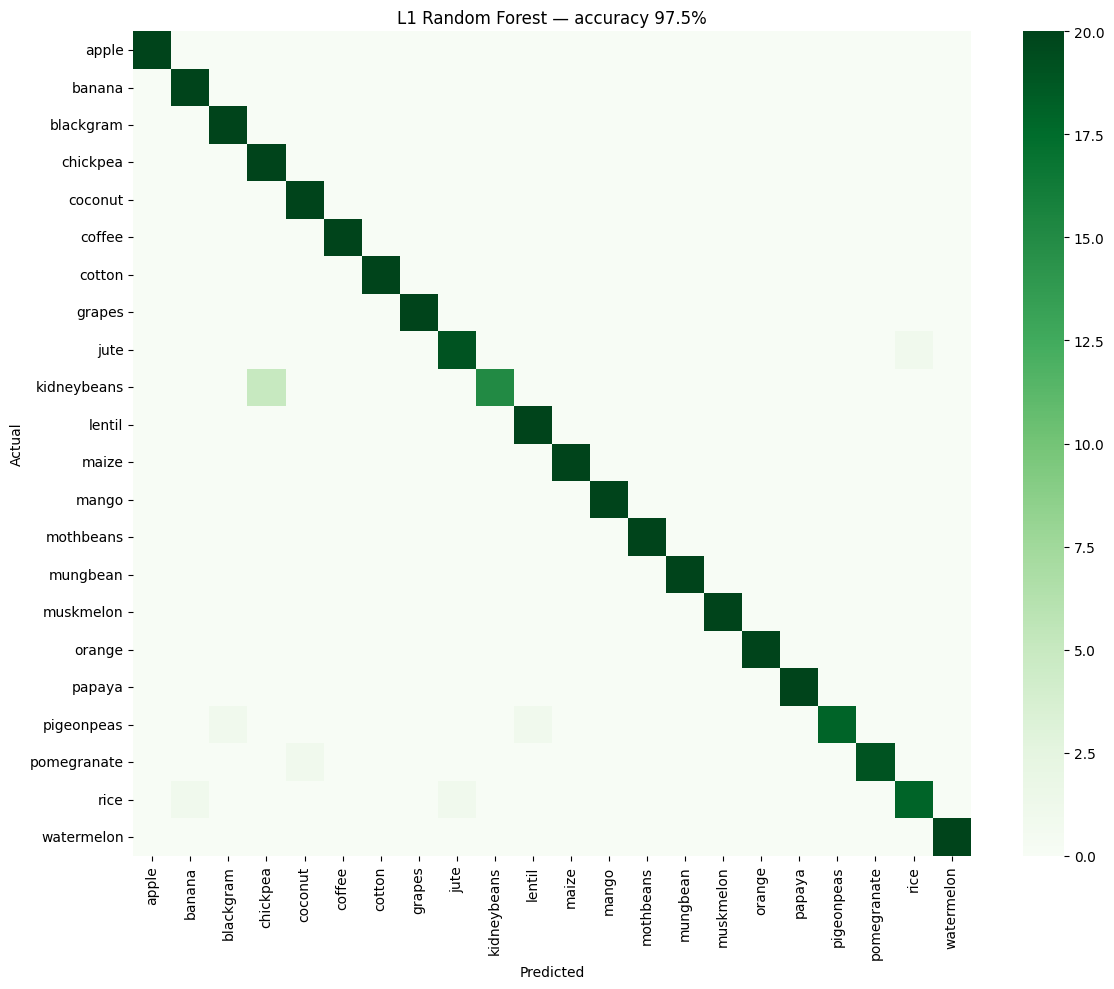

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt="d", cmap="Greens",
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.title(f"L1 Random Forest — accuracy {metrics_a['accuracy_pct']}%")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("panel_a_rf_confusion.png", dpi=150)
plt.show()

from google.colab import files
files.download("panel_a_rf_confusion.png")
files.download("metrics_a.json")

In [7]:
joblib.dump(rf, "rf_suitability.pkl")
files.download("rf_suitability.pkl")
print("Save to Mac: ml-models/figures/panel_a_rf_confusion.png + ml-models/artifacts/metrics_a.json + rf_suitability.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Save to Mac: ml-models/figures/panel_a_rf_confusion.png + ml-models/artifacts/metrics_a.json + rf_suitability.pkl
